In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/prediction_monitoring.csv"
)

df.head()

,container_id,timestamp,commodity,temperature,humidity,vibration,condition,predicted_condition,prediction_confidence,confidence_category,prediction_status,monitoring_level
0,CONT_001,2026-09-10 17:39:32.831215,Avocado,3.94,71.79,0.29,WARNING,WARNING,0.995,HIGH CONFIDENCE,CORRECT,MONITOR
1,CONT_004,2026-09-10 17:39:34.852445,Mango,11.72,88.98,0.12,NORMAL,NORMAL,1.000,HIGH CONFIDENCE,CORRECT,NORMAL
2,CONT_005,2026-09-10 17:39:36.870612,Tomato,10.18,91.05,0.15,NORMAL,NORMAL,1.000,HIGH CONFIDENCE,CORRECT,NORMAL
3,CONT_005,2026-09-10 17:39:38.890192,Avocado,6.54,85.30,0.17,NORMAL,NORMAL,0.995,HIGH CONFIDENCE,CORRECT,NORMAL
4,CONT_005,2026-09-10 17:39:40.899424,Tomato,14.06,100.00,0.33,WARNING,WARNING,1.000,HIGH CONFIDENCE,CORRECT,MONITOR


In [3]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1785, 12)

Columns:
['container_id', 'timestamp', 'commodity', 'temperature', 'humidity', 'vibration', 'condition', 'predicted_condition', 'prediction_confidence', 'confidence_category', 'prediction_status', 'monitoring_level']

Missing values:
container_id             0
timestamp                0
commodity                0
temperature              0
humidity                 0
vibration                0
condition                0
predicted_condition      0
prediction_confidence    0
confidence_category      0
prediction_status        0
monitoring_level         0
dtype: int64


In [4]:
prediction_counts = (
    df["predicted_condition"]
    .value_counts()
)

prediction_counts

predicted_condition
NORMAL     1249
WARNING     352
ANOMALY     184
Name: count, dtype: int64

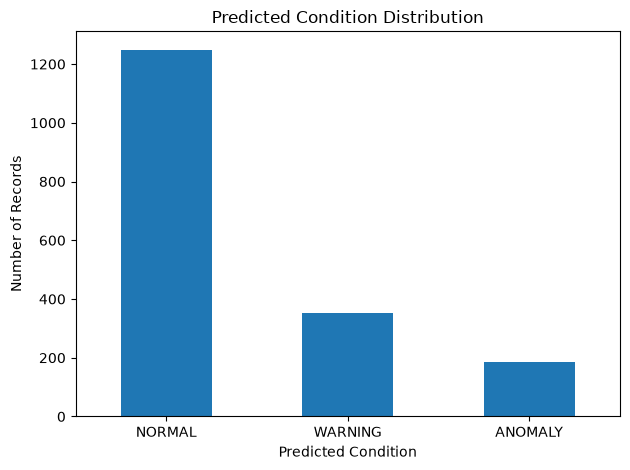

In [5]:
prediction_counts.plot(
    kind="bar",
    title="Predicted Condition Distribution"
)

plt.xlabel("Predicted Condition")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
df["prediction_confidence"].describe()

count    1785.000000
mean        0.995056
std         0.018252
min         0.795000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: prediction_confidence, dtype: float64

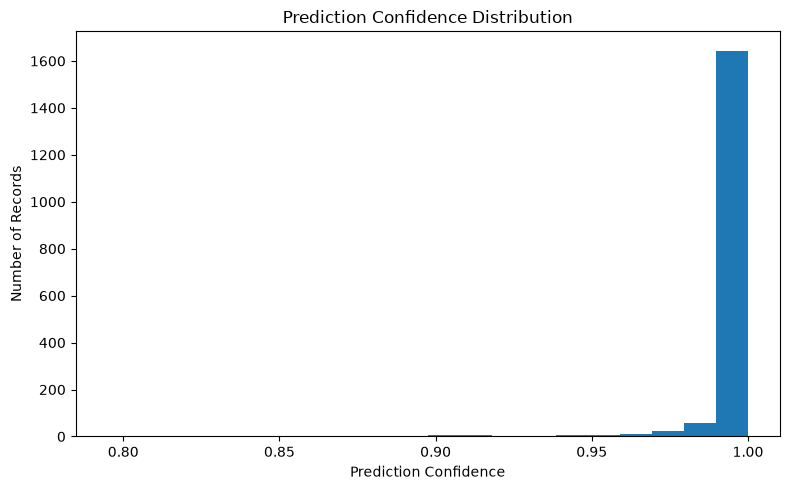

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["prediction_confidence"],
    bins=20
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [8]:
confidence_counts = (
    df["confidence_category"]
    .value_counts()
)

confidence_counts

confidence_category
HIGH CONFIDENCE      1767
MEDIUM CONFIDENCE      18
Name: count, dtype: int64

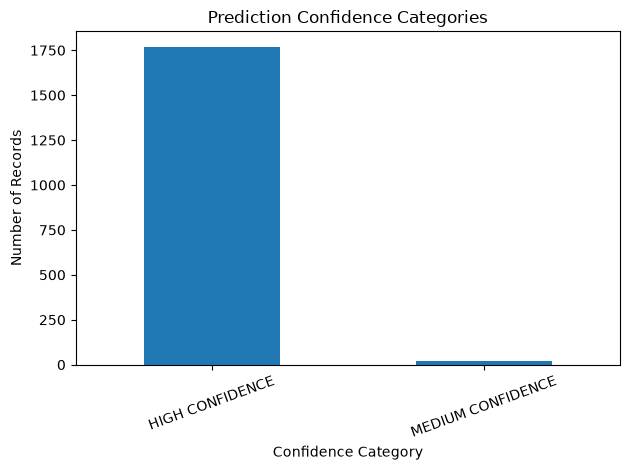

In [9]:
confidence_counts.plot(
    kind="bar",
    title="Prediction Confidence Categories"
)

plt.xlabel("Confidence Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [10]:
monitoring_counts = (
    df["monitoring_level"]
    .value_counts()
)

monitoring_counts

monitoring_level
NORMAL              1249
MONITOR              352
ANOMALY DETECTED     184
Name: count, dtype: int64

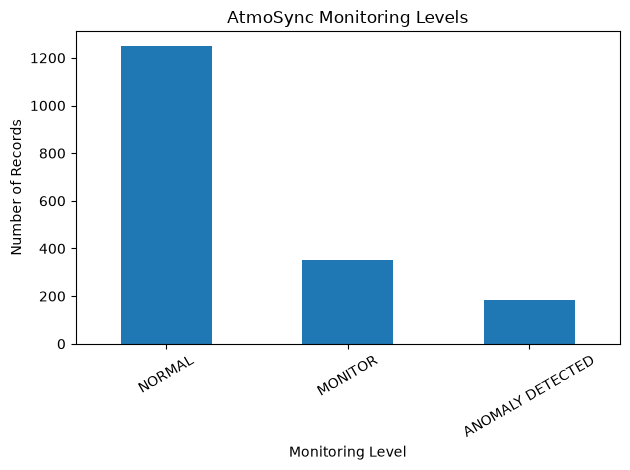

In [11]:
monitoring_counts.plot(
    kind="bar",
    title="AtmoSync Monitoring Levels"
)

plt.xlabel("Monitoring Level")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
comparison = pd.crosstab(
    df["condition"],
    df["predicted_condition"]
)

comparison

predicted_condition,ANOMALY,NORMAL,WARNING
condition,,,
ANOMALY,184,0,0
NORMAL,0,1249,0
WARNING,0,0,352


In [14]:
low_confidence = df[
    df["prediction_confidence"] < 0.90
].sort_values(
    "prediction_confidence"
)

low_confidence[
    [
        "container_id",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "condition",
        "predicted_condition",
        "prediction_confidence",
        "monitoring_level"
    ]
]

,container_id,commodity,temperature,humidity,vibration,condition,predicted_condition,prediction_confidence,monitoring_level
545,CONT_004,Tomato,10.84,92.44,0.2,NORMAL,NORMAL,0.795,NORMAL
333,CONT_003,Tomato,10.32,89.03,0.2,NORMAL,NORMAL,0.815,NORMAL
1674,CONT_005,Avocado,11.23,94.26,0.2,NORMAL,NORMAL,0.830,NORMAL
510,CONT_003,Banana,13.45,88.38,0.2,NORMAL,NORMAL,0.840,NORMAL
233,CONT_003,Banana,13.29,89.59,0.2,NORMAL,NORMAL,0.840,NORMAL
1434,CONT_005,Banana,13.86,88.45,0.2,NORMAL,NORMAL,0.845,NORMAL
1218,CONT_003,Tomato,11.14,88.89,0.2,NORMAL,NORMAL,0.845,NORMAL
104,CONT_001,Avocado,5.25,92.05,0.2,NORMAL,NORMAL,0.855,NORMAL
785,CONT_005,Mango,11.40,85.56,0.2,NORMAL,NORMAL,0.855,NORMAL
1165,CONT_005,Avocado,7.10,89.01,0.2,NORMAL,NORMAL,0.855,NORMAL


In [15]:
anomalies = df[
    df["predicted_condition"] == "ANOMALY"
].copy()

print("Predicted anomalies:", len(anomalies))

anomalies[
    [
        "container_id",
        "timestamp",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "prediction_confidence",
        "monitoring_level"
    ]
].head(20)

Predicted anomalies: 184


,container_id,timestamp,commodity,temperature,humidity,vibration,prediction_confidence,monitoring_level
12,CONT_002,2026-09-10 17:39:52.847854,Banana,8.84,72.70,0.44,1.000,ANOMALY DETECTED
39,CONT_005,2026-09-10 17:40:19.383720,Tomato,16.07,65.47,0.39,0.995,ANOMALY DETECTED
50,CONT_002,2026-09-10 17:40:31.353149,Avocado,-1.92,63.09,0.48,1.000,ANOMALY DETECTED
60,CONT_001,2026-09-10 17:40:41.900585,Mango,4.03,72.37,0.54,1.000,ANOMALY DETECTED
65,CONT_003,2026-09-10 17:40:46.375099,Mango,18.33,100.00,0.35,1.000,ANOMALY DETECTED
66,CONT_002,2026-09-10 17:40:48.354105,Banana,18.68,100.00,0.37,1.000,ANOMALY DETECTED
73,CONT_002,2026-09-10 17:40:54.421271,Avocado,17.81,62.32,0.38,0.995,ANOMALY DETECTED
77,CONT_002,2026-09-10 17:41:00.188032,Mango,5.33,61.89,0.58,1.000,ANOMALY DETECTED
80,CONT_004,2026-09-10 17:41:04.307125,Avocado,16.14,100.00,0.45,0.995,ANOMALY DETECTED
86,CONT_004,2026-09-10 17:41:10.323341,Tomato,3.06,63.43,0.45,0.995,ANOMALY DETECTED


In [16]:
container_monitoring = pd.crosstab(
    df["container_id"],
    df["predicted_condition"]
)

container_monitoring

predicted_condition,ANOMALY,NORMAL,WARNING
container_id,,,
CONT_001,36,242,62
CONT_002,35,239,65
CONT_003,37,250,82
CONT_004,36,246,81
CONT_005,40,272,62


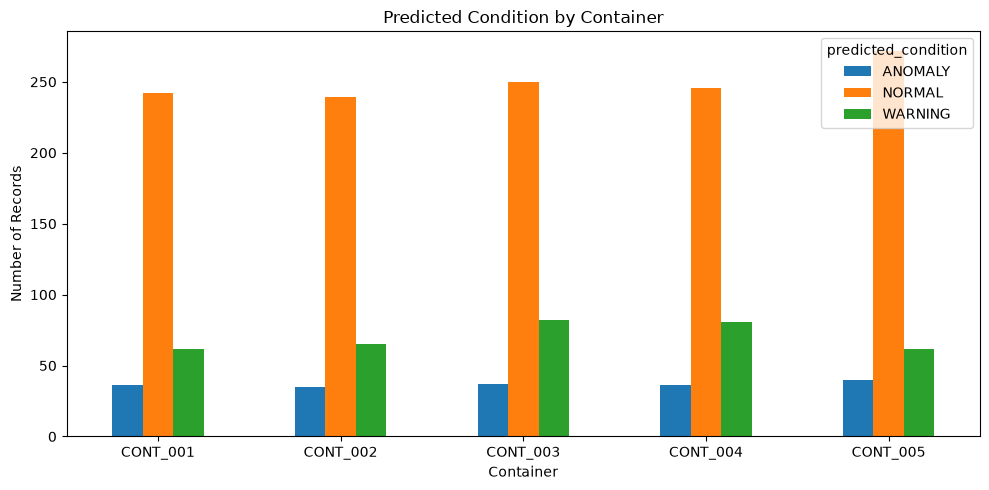

In [17]:
container_monitoring.plot(
    kind="bar",
    figsize=(10, 5),
    title="Predicted Condition by Container"
)

plt.xlabel("Container")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
commodity_monitoring = pd.crosstab(
    df["commodity"],
    df["predicted_condition"]
)

commodity_monitoring

predicted_condition,ANOMALY,NORMAL,WARNING
commodity,,,
Avocado,53,318,71
Banana,41,277,96
Mango,51,322,97
Tomato,39,332,88


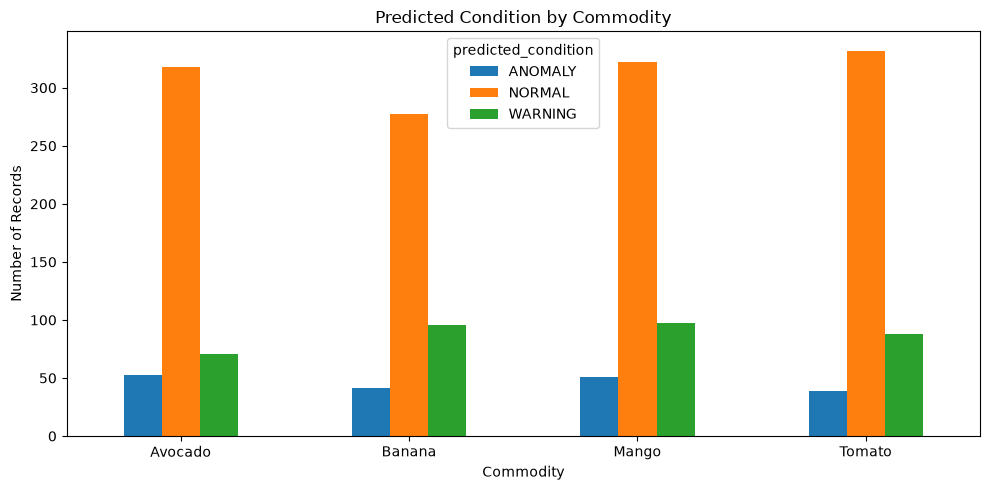

In [19]:
commodity_monitoring.plot(
    kind="bar",
    figsize=(10, 5),
    title="Predicted Condition by Commodity"
)

plt.xlabel("Commodity")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

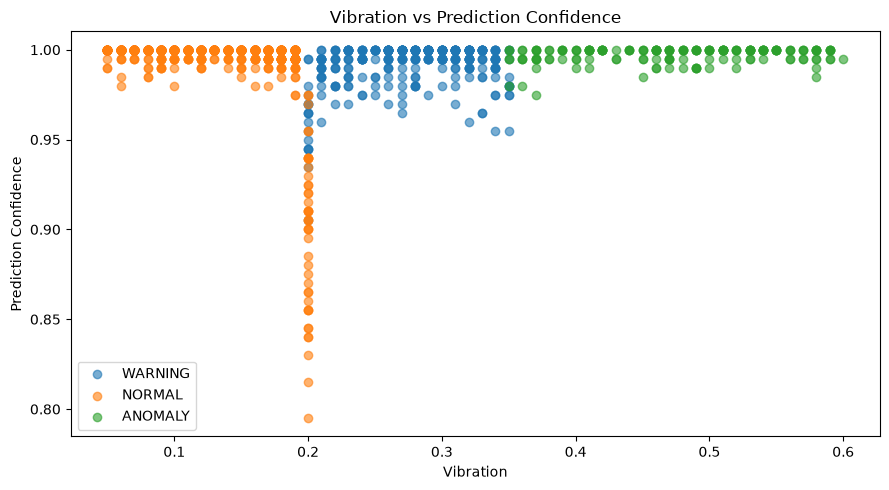

In [20]:
plt.figure(figsize=(9, 5))

for condition in df["predicted_condition"].unique():

    subset = df[
        df["predicted_condition"] == condition
    ]

    plt.scatter(
        subset["vibration"],
        subset["prediction_confidence"],
        label=condition,
        alpha=0.6
    )

plt.title("Vibration vs Prediction Confidence")
plt.xlabel("Vibration")
plt.ylabel("Prediction Confidence")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
monitoring_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Predicted Normal",
        "Predicted Warning",
        "Predicted Anomaly",
        "High Confidence",
        "Medium Confidence",
        "Low Confidence"
    ],
    "Value": [
        len(df),
        (df["predicted_condition"] == "NORMAL").sum(),
        (df["predicted_condition"] == "WARNING").sum(),
        (df["predicted_condition"] == "ANOMALY").sum(),
        (df["confidence_category"] == "HIGH CONFIDENCE").sum(),
        (df["confidence_category"] == "MEDIUM CONFIDENCE").sum(),
        (df["confidence_category"] == "LOW CONFIDENCE").sum()
    ]
})

monitoring_summary

,Metric,Value
0,Total Records,1785
1,Predicted Normal,1249
2,Predicted Warning,352
3,Predicted Anomaly,184
4,High Confidence,1767
5,Medium Confidence,18
6,Low Confidence,0


In [22]:
monitoring_summary.to_csv(
    "../data/processed/day10_monitoring_summary.csv",
    index=False
)

print("Monitoring summary saved.")

Monitoring summary saved.


In [23]:
confidence_percentage = (
    df["confidence_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

confidence_percentage

confidence_category
HIGH CONFIDENCE      98.99
MEDIUM CONFIDENCE     1.01
Name: proportion, dtype: float64

In [24]:
anomaly_percentage = (
    (df["predicted_condition"] == "ANOMALY").sum()
    / len(df)
    * 100
)

print(
    f"Predicted anomaly percentage: "
    f"{anomaly_percentage:.2f}%"
)

Predicted anomaly percentage: 10.31%


In [25]:
container_anomaly_rate = (
    df.assign(
        anomaly_flag=(
            df["predicted_condition"] == "ANOMALY"
        )
    )
    .groupby("container_id")["anomaly_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

container_anomaly_rate

container_id
CONT_005    10.70
CONT_001    10.59
CONT_002    10.32
CONT_003    10.03
CONT_004     9.92
Name: anomaly_flag, dtype: float64

In [26]:
commodity_anomaly_rate = (
    df.assign(
        anomaly_flag=(
            df["predicted_condition"] == "ANOMALY"
        )
    )
    .groupby("commodity")["anomaly_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

commodity_anomaly_rate

commodity
Avocado    11.99
Mango      10.85
Banana      9.90
Tomato      8.50
Name: anomaly_flag, dtype: float64

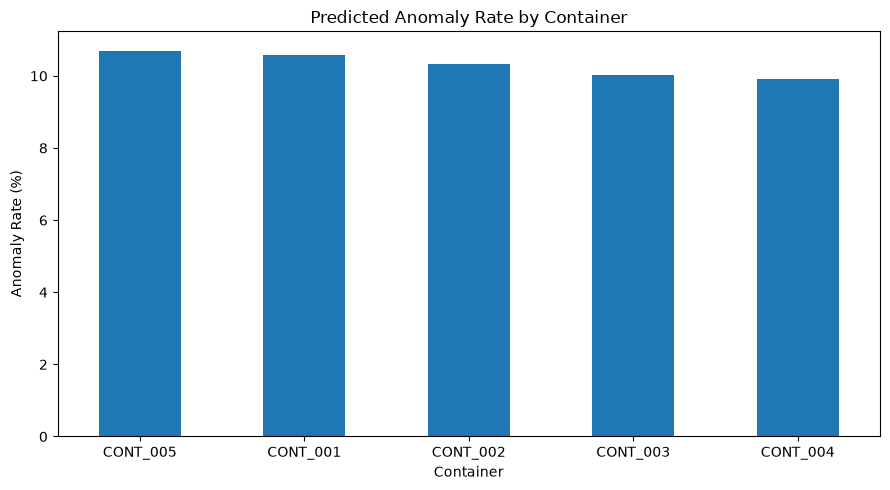

In [27]:
container_anomaly_rate.plot(
    kind="bar",
    figsize=(9, 5),
    title="Predicted Anomaly Rate by Container"
)

plt.xlabel("Container")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

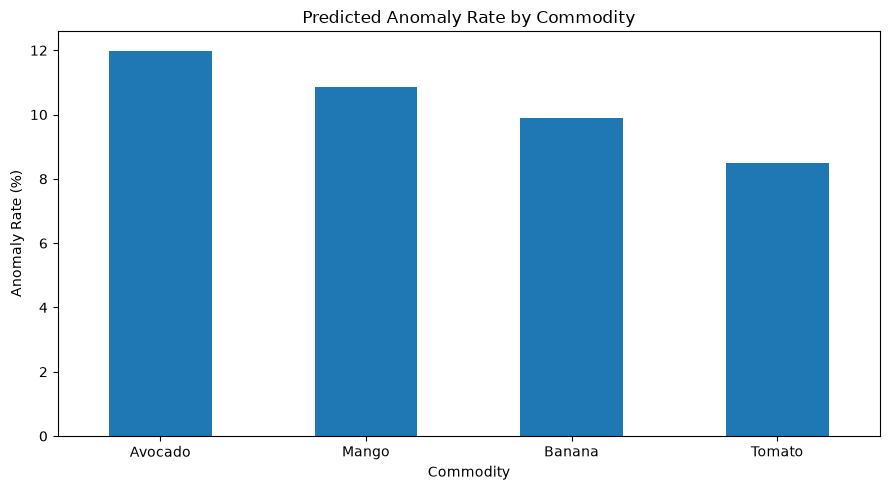

In [28]:
commodity_anomaly_rate.plot(
    kind="bar",
    figsize=(9, 5),
    title="Predicted Anomaly Rate by Commodity"
)

plt.xlabel("Commodity")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
confidence_percentage = (
    df["confidence_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

confidence_percentage

confidence_category
HIGH CONFIDENCE      98.99
MEDIUM CONFIDENCE     1.01
Name: proportion, dtype: float64

In [31]:
container_anomaly_rate = (
    df.assign(
        anomaly_flag=df["predicted_condition"] == "ANOMALY"
    )
    .groupby("container_id")["anomaly_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

container_anomaly_rate

container_id
CONT_005    10.70
CONT_001    10.59
CONT_002    10.32
CONT_003    10.03
CONT_004     9.92
Name: anomaly_flag, dtype: float64

In [33]:
commodity_anomaly_rate = (
    df.assign(
        anomaly_flag=df["predicted_condition"] == "ANOMALY"
    )
    .groupby("commodity")["anomaly_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

commodity_anomaly_rate

commodity
Avocado    11.99
Mango      10.85
Banana      9.90
Tomato      8.50
Name: anomaly_flag, dtype: float64

In [34]:
confidence_percentage = (
    df["confidence_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

confidence_percentage

confidence_category
HIGH CONFIDENCE      98.99
MEDIUM CONFIDENCE     1.01
Name: proportion, dtype: float64

In [35]:
container_anomaly_rate = (
    df.assign(
        anomaly_flag=df["predicted_condition"] == "ANOMALY"
    )
    .groupby("container_id")["anomaly_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

container_anomaly_rate

container_id
CONT_005    10.70
CONT_001    10.59
CONT_002    10.32
CONT_003    10.03
CONT_004     9.92
Name: anomaly_flag, dtype: float64

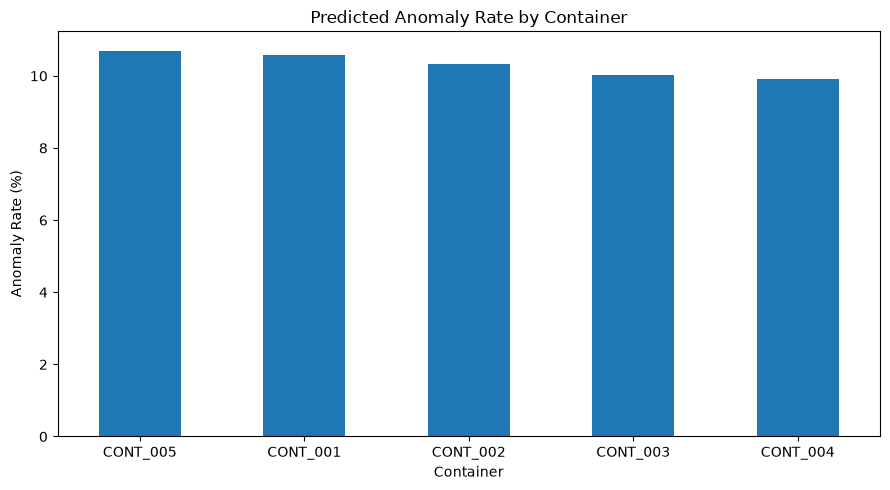

In [36]:
container_anomaly_rate.plot(
    kind="bar",
    figsize=(9, 5),
    title="Predicted Anomaly Rate by Container"
)

plt.xlabel("Container")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
commodity_anomaly_rate = (
    df.assign(
        anomaly_flag=df["predicted_condition"] == "ANOMALY"
    )
    .groupby("commodity")["anomaly_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

commodity_anomaly_rate

commodity
Avocado    11.99
Mango      10.85
Banana      9.90
Tomato      8.50
Name: anomaly_flag, dtype: float64

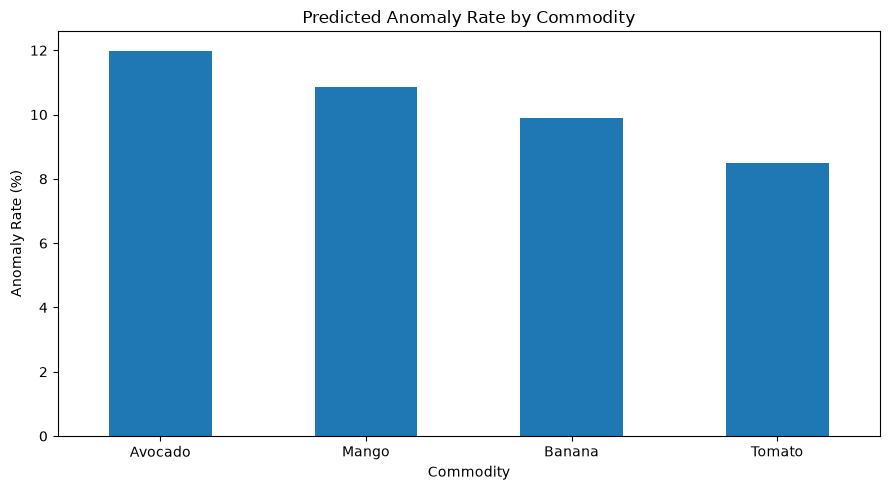

In [38]:
commodity_anomaly_rate.plot(
    kind="bar",
    figsize=(9, 5),
    title="Predicted Anomaly Rate by Commodity"
)

plt.xlabel("Commodity")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Predicted Normal",
        "Predicted Warning",
        "Predicted Anomaly",
        "Anomaly Percentage",
        "High Confidence",
        "Medium Confidence",
        "Low Confidence",
        "Minimum Prediction Confidence",
        "Mean Prediction Confidence"
    ],
    "Value": [
        len(df),
        (df["predicted_condition"] == "NORMAL").sum(),
        (df["predicted_condition"] == "WARNING").sum(),
        (df["predicted_condition"] == "ANOMALY").sum(),
        round(
            (df["predicted_condition"] == "ANOMALY").mean() * 100,
            2
        ),
        (df["confidence_category"] == "HIGH CONFIDENCE").sum(),
        (df["confidence_category"] == "MEDIUM CONFIDENCE").sum(),
        (df["confidence_category"] == "LOW CONFIDENCE").sum(),
        round(df["prediction_confidence"].min(), 3),
        round(df["prediction_confidence"].mean(), 3)
    ]
})

final_summary

,Metric,Value
0,Total Records,1785.000
1,Predicted Normal,1249.000
2,Predicted Warning,352.000
3,Predicted Anomaly,184.000
4,Anomaly Percentage,10.310
5,High Confidence,1767.000
6,Medium Confidence,18.000
7,Low Confidence,0.000
8,Minimum Prediction Confidence,0.795
9,Mean Prediction Confidence,0.995
